In [16]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.linear_model import LogisticRegression

# Title

### Setting up and cleaning initial pandas dataframes

In [17]:
# Load the csv into a pandas database
netflix = pd.read_csv('netflix_titles.csv', keep_default_na=False)
netflix.head(5)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,,,,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [18]:
# Remove director, cast, dated_added, and description columns 
# since we aren't going to be using them in our project.
netflix_cleaned = netflix.drop(columns=['director', 'cast', 'date_added', 'description'])
netflix_cleaned = netflix_cleaned[netflix_cleaned['country'] != '']
#netflix_cleaned = netflix_cleaned[netflix_cleaned['rating'] != '']
#netflix_cleaned = netflix_cleaned[netflix_cleaned['rating'] != 'NR']
netflix_cleaned.head(5)

,show_id,type,title,country,release_year,rating,duration,listed_in
0,s1,Movie,Dick Johnson Is Dead,United States,2020,PG-13,90 min,Documentaries
1,s2,TV Show,Blood & Water,South Africa,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries"
4,s5,TV Show,Kota Factory,India,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ..."
7,s8,Movie,Sankofa,"United States, Ghana, Burkina Faso, United Kin...",1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies"
8,s9,TV Show,The Great British Baking Show,United Kingdom,2021,TV-14,9 Seasons,"British TV Shows, Reality TV"


In [19]:
# Sub-database holding just movies
netflix_movies = netflix_cleaned[netflix_cleaned['type'] == 'Movie']
netflix_movies

,show_id,type,title,country,release_year,rating,duration,listed_in
0,s1,Movie,Dick Johnson Is Dead,United States,2020,PG-13,90 min,Documentaries
7,s8,Movie,Sankofa,"United States, Ghana, Burkina Faso, United Kin...",1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies"
9,s10,Movie,The Starling,United States,2021,PG-13,104 min,"Comedies, Dramas"
12,s13,Movie,Je Suis Karl,"Germany, Czech Republic",2021,TV-MA,127 min,"Dramas, International Movies"
24,s25,Movie,Jeans,India,1998,TV-14,166 min,"Comedies, International Movies, Romantic Movies"
...,...,...,...,...,...,...,...,...
8801,s8802,Movie,Zinzana,"United Arab Emirates, Jordan",2015,TV-MA,96 min,"Dramas, International Movies, Thrillers"
8802,s8803,Movie,Zodiac,United States,2007,R,158 min,"Cult Movies, Dramas, Thrillers"
8804,s8805,Movie,Zombieland,United States,2009,R,88 min,"Comedies, Horror Movies"
8805,s8806,Movie,Zoom,United States,2006,PG,88 min,"Children & Family Movies, Comedies"


In [20]:
# Sub-database holding just tv shows
netflix_shows = netflix_cleaned[netflix_cleaned['type'] == 'TV Show']
netflix_shows

,show_id,type,title,country,release_year,rating,duration,listed_in
1,s2,TV Show,Blood & Water,South Africa,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries"
4,s5,TV Show,Kota Factory,India,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ..."
8,s9,TV Show,The Great British Baking Show,United Kingdom,2021,TV-14,9 Seasons,"British TV Shows, Reality TV"
15,s16,TV Show,Dear White People,United States,2021,TV-MA,4 Seasons,"TV Comedies, TV Dramas"
17,s18,TV Show,Falsa identidad,Mexico,2020,TV-MA,2 Seasons,"Crime TV Shows, Spanish-Language TV Shows, TV ..."
...,...,...,...,...,...,...,...,...
8780,s8781,TV Show,Yo-Kai Watch,United States,2015,TV-Y7,1 Season,"Anime Series, Kids' TV"
8795,s8796,TV Show,Yu-Gi-Oh! Arc-V,"Japan, Canada",2015,TV-Y7,2 Seasons,"Anime Series, Kids' TV"
8796,s8797,TV Show,Yunus Emre,Turkey,2016,TV-PG,2 Seasons,"International TV Shows, TV Dramas"
8797,s8798,TV Show,Zak Storm,"United States, France, South Korea, Indonesia",2016,TV-Y7,3 Seasons,Kids' TV


### Sorting Data by Ratings for Visualization

In [21]:
ratings_movie = {
    # G
    'G': 'G', 'TV-G': 'G', 'TV-Y': 'G', 'TV-Y7': 'G', 'TV-Y7-FV': 'G',

    # PG
    'PG': 'PG', 'TV-PG': 'PG',

    # PG-13
    'PG-13': 'PG-13', 'TV-14': 'PG-13',

    # R
    'R': 'R', 'NC-17': 'R', 'TV-MA': 'R',

    # UR
    'UR': 'UR'
}

netflix_movies = netflix_movies.copy()
netflix_movies.loc[:, 'rating'] = (
    netflix_movies['rating']
    .str.strip()
    .str.upper()
    .map(ratings_movie)
    .fillna('UR')
)

netflix_movies_filtered = netflix_movies.groupby(['release_year', 'rating']).size().reset_index(name='count')
netflix_movies_filtered

,release_year,rating,count
0,1942,PG-13,2
1,1943,PG,3
2,1944,PG,1
3,1944,PG-13,2
4,1945,PG-13,2
...,...,...,...
232,2020,R,250
233,2021,G,12
234,2021,PG,21
235,2021,PG-13,53


In [22]:
ratings_show = {
    # G
    'G': 'G', 'TV-G': 'G', 'TV-Y': 'G', 'TV-Y7': 'G', 'TV-Y7-FV': 'G',

    # PG
    'PG': 'PG', 'TV-PG': 'PG',

    # PG-13
    'PG-13': 'PG-13', 'TV-14': 'PG-13',

    # R
    'R': 'R', 'NC-17': 'R', 'TV-MA': 'R',

    # UR
    'UR': 'UR', 'NR': 'UR'
}

netflix_shows = netflix_shows.copy()
netflix_shows.loc[:, 'rating'] = (
    netflix_shows['rating']
    .fillna('UR')
    .astype(str)
    .str.strip()
    .str.upper()
    .map(ratings_show)
    .fillna('UR')
)

netflix_shows_filtered = netflix_shows.groupby(['release_year', 'rating']).size().reset_index(name='count')
netflix_shows_filtered

,release_year,rating,count
0,1945,R,1
1,1946,PG-13,1
2,1963,PG-13,1
3,1967,G,1
4,1972,R,1
...,...,...,...
113,2020,R,233
114,2021,G,38
115,2021,PG,13
116,2021,PG-13,55


### Graphing Data

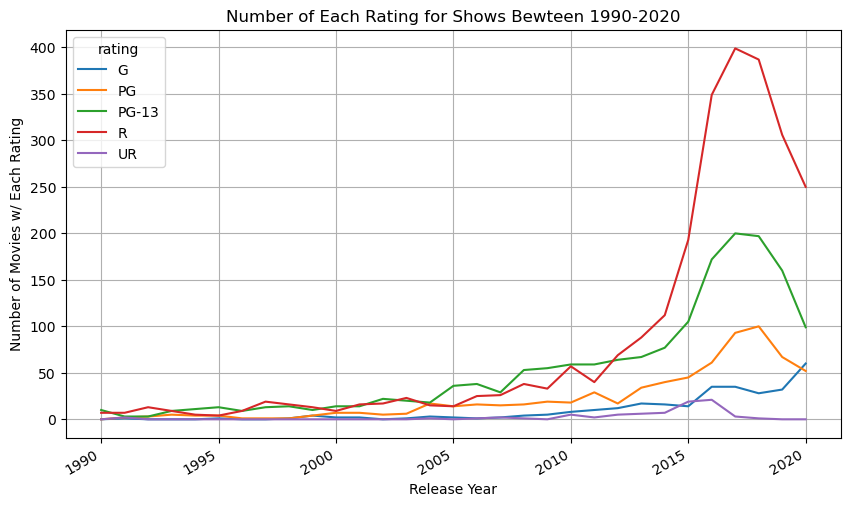

In [23]:
netflix_movies_agg = netflix_movies_filtered.groupby(['release_year', 'rating'])['count'].sum().reset_index()
pivoted_counts = netflix_movies_agg.pivot(index='release_year', columns='rating', values='count').fillna(0)
pivoted_counts = pivoted_counts.sort_index().loc[1990:2020]
pivoted_counts.plot(kind='line', figsize=(10, 6))

plt.title("Number of Each Rating for Shows Bewteen 1990-2020")
plt.xlabel("Release Year")
plt.ylabel("Number of Movies w/ Each Rating")

plt.grid(True)
plt.gcf().autofmt_xdate()
plt.show()

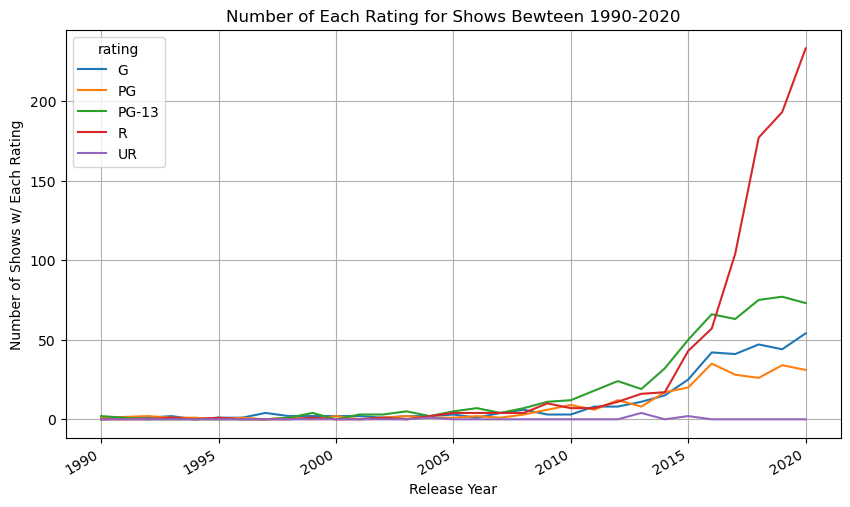

In [24]:
netflix_shows_agg = netflix_shows_filtered.groupby(['release_year', 'rating']).sum().reset_index()
pivoted_counts = netflix_shows_agg.pivot(index='release_year', columns='rating', values='count').fillna(0)
pivoted_counts = pivoted_counts.sort_index().loc[1990:2020]
pivoted_counts.plot(kind='line', figsize=(10, 6))

plt.title("Number of Each Rating for Shows Bewteen 1990-2020")
plt.xlabel("Release Year")
plt.ylabel("Number of Shows w/ Each Rating")

plt.grid(True)
plt.gcf().autofmt_xdate()
plt.show()

### Splitting up the 'listed_in' column for visualitation and future models

In [25]:
count = (
    netflix_movies['listed_in']
    .str.split(',')
    .explode()
    .str.strip()
    .value_counts()
)
count

International Movies        2543
Dramas                      2317
Comedies                    1580
Action & Adventure           817
Documentaries                794
Independent Movies           745
Romantic Movies              588
Thrillers                    549
Children & Family Movies     535
Horror Movies                340
Music & Musicals             328
Stand-Up Comedy              311
Sci-Fi & Fantasy             242
Sports Movies                201
Classic Movies               115
LGBTQ Movies                  97
Cult Movies                   70
Faith & Spirituality          63
Anime Features                63
Movies                        34
Name: listed_in, dtype: int64

In [26]:
count = (
    netflix_shows['listed_in']
    .str.split(',')   # turn "apple,banana" → ['apple','banana']
    .explode()        # flatten
    .str.strip()      # remove spaces like " banana"
    .value_counts()   # count
)
count

International TV Shows          1128
TV Dramas                        663
TV Comedies                      501
Crime TV Shows                   421
Kids' TV                         370
Docuseries                       330
Romantic TV Shows                299
British TV Shows                 237
Reality TV                       205
Anime Series                     154
TV Action & Adventure            153
Spanish-Language TV Shows        145
Korean TV Shows                  136
TV Mysteries                      92
Science & Nature TV               82
TV Sci-Fi & Fantasy               79
TV Horror                         72
Teen TV Shows                     66
TV Thrillers                      53
Stand-Up Comedy & Talk Shows      47
Classic & Cult TV                 27
TV Shows                           9
Name: listed_in, dtype: int64

### Logistic Regression


Question: Does the duraton of a movie/show influence its rating?
- Using "duration" to predict "rating"
- Duration for movies is in number of minutes
- Duration for shows is in number of seasons

In [27]:
""" Setting up movie data """
# List of most common movie ratings
possible_movie_ratings = ['G', 'PG', 'PG-13', 'R']

# Copies the rating and duration columns from the original netflix movie df
movie_rating_duration = netflix_movies[['rating', 'duration']].copy()

# Removes any ratings that don't match the list above.
# We need to since there are some movies with the 'UR' rating (un-rated), as well as just invalid entries
movie_rating_duration = movie_rating_duration[movie_rating_duration["rating"].isin(possible_movie_ratings)].reset_index(drop=True)

# Turns the duration into an integer of minutes instead of it being a string with ' min' at the end
movie_rating_duration["duration"] = movie_rating_duration["duration"].str[:-4].astype(int)

movie_rating_duration

,rating,duration
0,PG-13,90
1,R,125
2,PG-13,104
3,R,127
4,PG-13,166
...,...,...
5604,R,96
5605,R,158
5606,R,88
5607,PG,88


In [28]:
""" Setting up show data """
# List of most common show ratings
possible_show_ratings = ['G', 'PG', 'PG-13', 'R']

# Copies the rating and duration columns from the original netflix movie df
show_rating_duration = netflix_shows[['rating', 'duration']].copy()

# Removes any ratings that don't match the list above
show_rating_duration = show_rating_duration[show_rating_duration["rating"].isin(possible_show_ratings)].reset_index(drop=True)

# Turns the duration into an integer of seasons instead of it being a string with 'Seasons' at the end
show_rating_duration["duration"] = show_rating_duration["duration"].str[:-7].astype(int)

show_rating_duration

,rating,duration
0,R,2
1,R,2
2,PG-13,9
3,R,4
4,R,2
...,...,...
2273,G,1
2274,G,2
2275,PG,2
2276,G,3


In [29]:
""" Getting the X and Y values for movies and shows to be used in logistic regression """
# Movie
X_movie = movie_rating_duration[["duration"]]
Y_movie = movie_rating_duration['rating']

# Show
X_show = show_rating_duration[['duration']]
Y_show = show_rating_duration['rating']

In [30]:
""" Make the models """
# Create logistic regression models
movie_model = LogisticRegression()
show_model = LogisticRegression()

movie_model.fit(X_movie, Y_movie)
show_model.fit(X_show, Y_show)



LogisticRegression()

In [31]:
""" Running probability models to get predictions """
movie_prob = movie_model.predict_proba(X_movie)
show_prob = show_model.predict_proba(X_show)


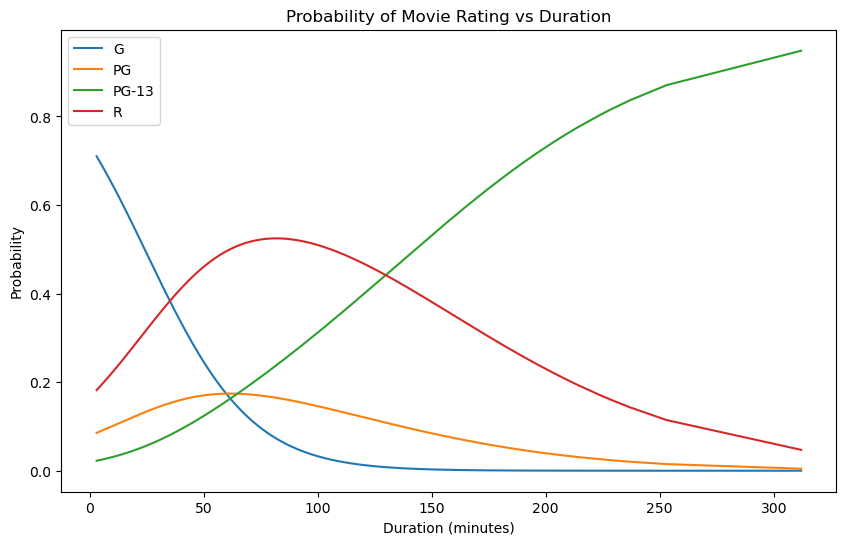

In [32]:
""" Display Movie Results """
movie_prob_df = pd.DataFrame(movie_prob, columns=possible_movie_ratings)
movie_prob_df["duration"] = X_movie["duration"].to_numpy()
movie_plot = movie_prob_df.sort_values("duration")

# movie_prob_df

plt.figure(figsize=(10,6))
for r in possible_movie_ratings:
    plt.plot(movie_plot["duration"], movie_plot[r], label=r)

plt.xlabel("Duration (minutes)")
plt.ylabel("Probability")
plt.title("Probability of Movie Rating vs Duration")
plt.legend()
plt.show()


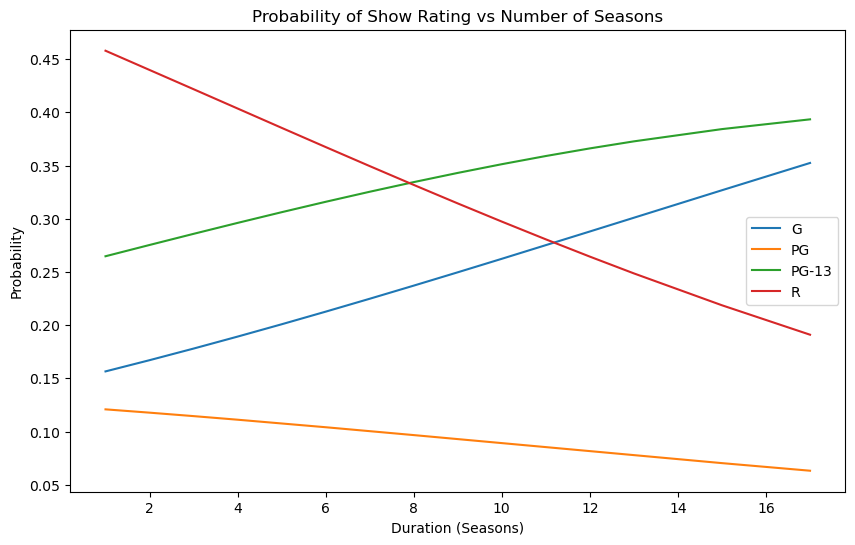

In [33]:
""" Display Show Results """
show_prob_df = pd.DataFrame(show_prob, columns=possible_show_ratings)
show_prob_df["duration"] = X_show["duration"].to_numpy()
show_plot = show_prob_df.sort_values("duration")

# show_prob_df

plt.figure(figsize=(10,6))
for r in possible_show_ratings:
    plt.plot(show_plot["duration"], show_plot[r], label=r)

plt.xlabel("Duration (Seasons)")
plt.ylabel("Probability")
plt.title("Probability of Show Rating vs Number of Seasons")
plt.legend()
plt.show()

### Random Forest

Question: Is their a correlation between the rating of a movie and both its title and genre?
- Looking for rating using the "title" and "listed_in" columns of both movies and shows

In [34]:
netflix_shows

,show_id,type,title,country,release_year,rating,duration,listed_in
1,s2,TV Show,Blood & Water,South Africa,2021,R,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries"
4,s5,TV Show,Kota Factory,India,2021,R,2 Seasons,"International TV Shows, Romantic TV Shows, TV ..."
8,s9,TV Show,The Great British Baking Show,United Kingdom,2021,PG-13,9 Seasons,"British TV Shows, Reality TV"
15,s16,TV Show,Dear White People,United States,2021,R,4 Seasons,"TV Comedies, TV Dramas"
17,s18,TV Show,Falsa identidad,Mexico,2020,R,2 Seasons,"Crime TV Shows, Spanish-Language TV Shows, TV ..."
...,...,...,...,...,...,...,...,...
8780,s8781,TV Show,Yo-Kai Watch,United States,2015,G,1 Season,"Anime Series, Kids' TV"
8795,s8796,TV Show,Yu-Gi-Oh! Arc-V,"Japan, Canada",2015,G,2 Seasons,"Anime Series, Kids' TV"
8796,s8797,TV Show,Yunus Emre,Turkey,2016,PG,2 Seasons,"International TV Shows, TV Dramas"
8797,s8798,TV Show,Zak Storm,"United States, France, South Korea, Indonesia",2016,G,3 Seasons,Kids' TV


In [35]:
netflix_movies

,show_id,type,title,country,release_year,rating,duration,listed_in
0,s1,Movie,Dick Johnson Is Dead,United States,2020,PG-13,90 min,Documentaries
7,s8,Movie,Sankofa,"United States, Ghana, Burkina Faso, United Kin...",1993,R,125 min,"Dramas, Independent Movies, International Movies"
9,s10,Movie,The Starling,United States,2021,PG-13,104 min,"Comedies, Dramas"
12,s13,Movie,Je Suis Karl,"Germany, Czech Republic",2021,R,127 min,"Dramas, International Movies"
24,s25,Movie,Jeans,India,1998,PG-13,166 min,"Comedies, International Movies, Romantic Movies"
...,...,...,...,...,...,...,...,...
8801,s8802,Movie,Zinzana,"United Arab Emirates, Jordan",2015,R,96 min,"Dramas, International Movies, Thrillers"
8802,s8803,Movie,Zodiac,United States,2007,R,158 min,"Cult Movies, Dramas, Thrillers"
8804,s8805,Movie,Zombieland,United States,2009,R,88 min,"Comedies, Horror Movies"
8805,s8806,Movie,Zoom,United States,2006,PG,88 min,"Children & Family Movies, Comedies"


### Preparing the Data
I will start by dropping irrelevant columns

In [36]:
movies_forest = netflix_movies[["title", "rating", "listed_in"]]
shows_forest = netflix_shows[["title", "rating", "listed_in"]]

In [37]:
movies_forest

,title,rating,listed_in
0,Dick Johnson Is Dead,PG-13,Documentaries
7,Sankofa,R,"Dramas, Independent Movies, International Movies"
9,The Starling,PG-13,"Comedies, Dramas"
12,Je Suis Karl,R,"Dramas, International Movies"
24,Jeans,PG-13,"Comedies, International Movies, Romantic Movies"
...,...,...,...
8801,Zinzana,R,"Dramas, International Movies, Thrillers"
8802,Zodiac,R,"Cult Movies, Dramas, Thrillers"
8804,Zombieland,R,"Comedies, Horror Movies"
8805,Zoom,PG,"Children & Family Movies, Comedies"


### Multi-Hot Encoding
Because out listed_in column is including multiple items in the column, we must manipulate the data so that our model can read it. We do this by performing multi-hot encoding, which will give each possible "listed_in" category a column, and a binary input describing if it is included in that show/movie or not

We will do this by using scikit-learn's MultiLabelBinarizer

Starting with movies dataframe

In [38]:
movies_forest

,title,rating,listed_in
0,Dick Johnson Is Dead,PG-13,Documentaries
7,Sankofa,R,"Dramas, Independent Movies, International Movies"
9,The Starling,PG-13,"Comedies, Dramas"
12,Je Suis Karl,R,"Dramas, International Movies"
24,Jeans,PG-13,"Comedies, International Movies, Romantic Movies"
...,...,...,...
8801,Zinzana,R,"Dramas, International Movies, Thrillers"
8802,Zodiac,R,"Cult Movies, Dramas, Thrillers"
8804,Zombieland,R,"Comedies, Horror Movies"
8805,Zoom,PG,"Children & Family Movies, Comedies"


In [39]:
movies_forest["listed_in"] = movies_forest["listed_in"].str.split(", ")
movies_forest

C:\Users\NickP\AppData\Local\Temp\ipykernel_15540\1675168003.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  movies_forest["listed_in"] = movies_forest["listed_in"].str.split(", ")


,title,rating,listed_in
0,Dick Johnson Is Dead,PG-13,[Documentaries]
7,Sankofa,R,"[Dramas, Independent Movies, International Mov..."
9,The Starling,PG-13,"[Comedies, Dramas]"
12,Je Suis Karl,R,"[Dramas, International Movies]"
24,Jeans,PG-13,"[Comedies, International Movies, Romantic Movies]"
...,...,...,...
8801,Zinzana,R,"[Dramas, International Movies, Thrillers]"
8802,Zodiac,R,"[Cult Movies, Dramas, Thrillers]"
8804,Zombieland,R,"[Comedies, Horror Movies]"
8805,Zoom,PG,"[Children & Family Movies, Comedies]"


In [40]:
movies_forest["listed_in"] = movies_forest["listed_in"].fillna("")
movies_forest

C:\Users\NickP\AppData\Local\Temp\ipykernel_15540\2451414714.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  movies_forest["listed_in"] = movies_forest["listed_in"].fillna("")


,title,rating,listed_in
0,Dick Johnson Is Dead,PG-13,[Documentaries]
7,Sankofa,R,"[Dramas, Independent Movies, International Mov..."
9,The Starling,PG-13,"[Comedies, Dramas]"
12,Je Suis Karl,R,"[Dramas, International Movies]"
24,Jeans,PG-13,"[Comedies, International Movies, Romantic Movies]"
...,...,...,...
8801,Zinzana,R,"[Dramas, International Movies, Thrillers]"
8802,Zodiac,R,"[Cult Movies, Dramas, Thrillers]"
8804,Zombieland,R,"[Comedies, Horror Movies]"
8805,Zoom,PG,"[Children & Family Movies, Comedies]"


In [41]:
# Call the binarizer
mlb = MultiLabelBinarizer()
# Movie Dataframe
transform_movies = mlb.fit_transform(movies_forest["listed_in"])
mlb.classes_

array(['Action & Adventure', 'Anime Features', 'Children & Family Movies',
       'Classic Movies', 'Comedies', 'Cult Movies', 'Documentaries',
       'Dramas', 'Faith & Spirituality', 'Horror Movies',
       'Independent Movies', 'International Movies', 'LGBTQ Movies',
       'Movies', 'Music & Musicals', 'Romantic Movies',
       'Sci-Fi & Fantasy', 'Sports Movies', 'Stand-Up Comedy',
       'Thrillers'], dtype=object)

In [42]:
reset_movies_listed_in = pd.DataFrame(transform_movies, columns=mlb.classes_, index=movies_forest.index)
reset_movies_listed_in

,Action & Adventure,Anime Features,Children & Family Movies,Classic Movies,Comedies,Cult Movies,Documentaries,Dramas,Faith & Spirituality,Horror Movies,Independent Movies,International Movies,LGBTQ Movies,Movies,Music & Musicals,Romantic Movies,Sci-Fi & Fantasy,Sports Movies,Stand-Up Comedy,Thrillers
0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0
7,0,0,0,0,0,0,0,1,0,0,1,1,0,0,0,0,0,0,0,0
9,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0
12,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0
24,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8801,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,1
8802,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,1
8804,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
8805,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [43]:
movies_forest_concat = pd.concat([movies_forest, reset_movies_listed_in], axis=1)
movies_forest_concat

,title,rating,listed_in,Action & Adventure,Anime Features,Children & Family Movies,Classic Movies,Comedies,Cult Movies,Documentaries,...,Independent Movies,International Movies,LGBTQ Movies,Movies,Music & Musicals,Romantic Movies,Sci-Fi & Fantasy,Sports Movies,Stand-Up Comedy,Thrillers
0,Dick Johnson Is Dead,PG-13,[Documentaries],0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
7,Sankofa,R,"[Dramas, Independent Movies, International Mov...",0,0,0,0,0,0,0,...,1,1,0,0,0,0,0,0,0,0
9,The Starling,PG-13,"[Comedies, Dramas]",0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
12,Je Suis Karl,R,"[Dramas, International Movies]",0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
24,Jeans,PG-13,"[Comedies, International Movies, Romantic Movies]",0,0,0,0,1,0,0,...,0,1,0,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8801,Zinzana,R,"[Dramas, International Movies, Thrillers]",0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,1
8802,Zodiac,R,"[Cult Movies, Dramas, Thrillers]",0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,1
8804,Zombieland,R,"[Comedies, Horror Movies]",0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
8805,Zoom,PG,"[Children & Family Movies, Comedies]",0,0,1,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0


### Multi-Hot Encoding Continued
Now we will do the same as above but with the shows dataframe

In [44]:
shows_forest["listed_in"] = shows_forest["listed_in"].str.split(", ")
shows_forest

C:\Users\NickP\AppData\Local\Temp\ipykernel_15540\2104494492.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  shows_forest["listed_in"] = shows_forest["listed_in"].str.split(", ")


,title,rating,listed_in
1,Blood & Water,R,"[International TV Shows, TV Dramas, TV Mysteries]"
4,Kota Factory,R,"[International TV Shows, Romantic TV Shows, TV..."
8,The Great British Baking Show,PG-13,"[British TV Shows, Reality TV]"
15,Dear White People,R,"[TV Comedies, TV Dramas]"
17,Falsa identidad,R,"[Crime TV Shows, Spanish-Language TV Shows, TV..."
...,...,...,...
8780,Yo-Kai Watch,G,"[Anime Series, Kids' TV]"
8795,Yu-Gi-Oh! Arc-V,G,"[Anime Series, Kids' TV]"
8796,Yunus Emre,PG,"[International TV Shows, TV Dramas]"
8797,Zak Storm,G,[Kids' TV]


In [45]:
shows_forest["listed_in"] = shows_forest["listed_in"].fillna("")
shows_forest

C:\Users\NickP\AppData\Local\Temp\ipykernel_15540\272750527.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  shows_forest["listed_in"] = shows_forest["listed_in"].fillna("")


,title,rating,listed_in
1,Blood & Water,R,"[International TV Shows, TV Dramas, TV Mysteries]"
4,Kota Factory,R,"[International TV Shows, Romantic TV Shows, TV..."
8,The Great British Baking Show,PG-13,"[British TV Shows, Reality TV]"
15,Dear White People,R,"[TV Comedies, TV Dramas]"
17,Falsa identidad,R,"[Crime TV Shows, Spanish-Language TV Shows, TV..."
...,...,...,...
8780,Yo-Kai Watch,G,"[Anime Series, Kids' TV]"
8795,Yu-Gi-Oh! Arc-V,G,"[Anime Series, Kids' TV]"
8796,Yunus Emre,PG,"[International TV Shows, TV Dramas]"
8797,Zak Storm,G,[Kids' TV]


In [46]:
mlb_show = MultiLabelBinarizer()
# Show Dataframe
transform_shows = mlb_show.fit_transform(movies_forest["listed_in"])
mlb_show.classes_
transform_shows.shape

(5691, 20)

In [47]:
reset_shows_listed_in = pd.DataFrame(transform_shows, columns=mlb_show.classes_, index=shows_forest.index)
reset_shows_listed_in

ValueError: Shape of passed values is (5691, 20), indices imply (2285, 20)